
Processing: afsana sadhick_1.dat


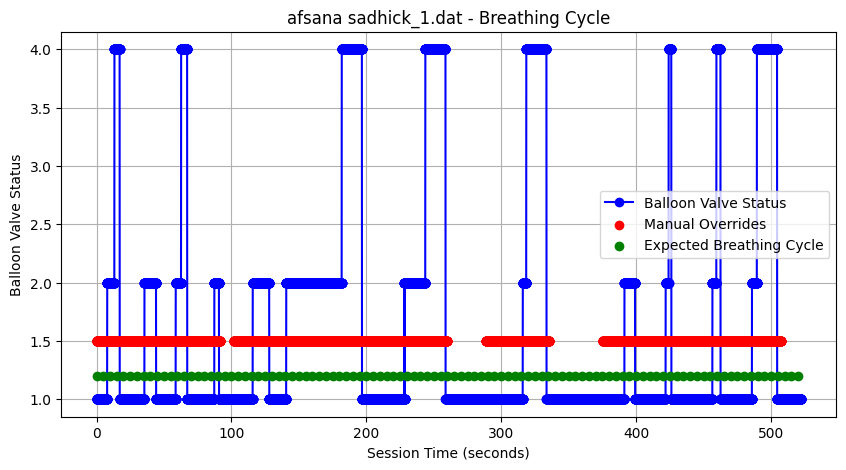

IndexError: Boolean index has wrong length: 26111 instead of 26135

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

# Column names based on provided dataset structure
COLUMN_NAMES = [
    "Session Time", "Volume (liters)", "Balloon Valve Status", "Patient Switch",
    "Gating Mode", "Gating Status", "Relay State"
]

# Function to load and preprocess breathing data
def load_breathing_data(file_path):
    """
    Reads a .dat file containing breathing signal data and extracts relevant columns.
    """
    data = pd.read_csv(file_path, delimiter=";", header=None, names=COLUMN_NAMES, engine='python')
    
    # Convert numeric columns
    data["Session Time"] = pd.to_numeric(data["Session Time"], errors='coerce')
    data["Balloon Valve Status"] = pd.to_numeric(data["Balloon Valve Status"], errors='coerce')
    data["Patient Switch"] = pd.to_numeric(data["Patient Switch"], errors='coerce')
    
    return data

# Function to plot breathing cycle
def plot_breathing_cycle(data, title="Breathing Cycle Analysis"):
    plt.figure(figsize=(10, 5))
    plt.plot(data["Session Time"], data["Balloon Valve Status"], marker='o', linestyle='-', color='b', label='Balloon Valve Status')
    
    # Mark manual overrides (Patient Switch enabled)
    manual_override_times = data[data["Patient Switch"] == 1]["Session Time"]
    plt.scatter(manual_override_times, np.ones_like(manual_override_times) * 1.5, color='red', label='Manual Overrides', zorder=3)

    # Mark expected breathing cycles (~5 sec intervals)
    expected_breathing_times = np.arange(0, data["Session Time"].max(), 5)
    plt.scatter(expected_breathing_times, np.ones_like(expected_breathing_times) * 1.2, color='green', label='Expected Breathing Cycle', zorder=3)

    plt.xlabel("Session Time (seconds)")
    plt.ylabel("Balloon Valve Status")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Function to analyze breathing irregularities
def analyze_irregularities(data):
    """
    Computes time intervals and detects anomalies.
    """
    time_intervals = np.diff(data["Session Time"].dropna())
    threshold = np.mean(time_intervals) + 2 * np.std(time_intervals)  # Define anomaly threshold
    anomalies = time_intervals > threshold
    abnormal_times = data["Session Time"].iloc[1:][anomalies]

    # Plot time intervals
    plt.figure(figsize=(10, 5))
    plt.plot(data["Session Time"].iloc[1:], time_intervals, marker='o', linestyle='-', color='b', label='Time Interval')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Anomaly Threshold')
    
    # Highlight abnormal intervals
    plt.scatter(abnormal_times, np.full_like(abnormal_times, threshold), color='red', label='Anomaly', zorder=3)

    plt.xlabel("Session Time (seconds)")
    plt.ylabel("Time Interval (seconds)")
    plt.title("Breathing Cycle Time Intervals")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Number of detected anomalies: {len(abnormal_times)}")
    return abnormal_times

# --- Main Execution ---
if __name__ == "__main__":
    # Get all .dat files
    dataset_files = glob.glob("*.dat")
    
    for file in dataset_files:
        print(f"\nProcessing: {file}")
        
        # Load data
        try:
            breathing_data = load_breathing_data(file)
        except Exception as e:
            print(f"Error loading {file}: {e}")
            continue
        
        # Plot breathing cycle
        plot_breathing_cycle(breathing_data, title=f"{file} - Breathing Cycle")

        # Analyze irregularities
        abnormal_points = analyze_irregularities(breathing_data)

        if len(abnormal_points) > 0:
            print(f"⚠️ Detected {len(abnormal_points)} anomalies in {file} at times: {list(abnormal_points)}")
        else:
            print(f"✅ No significant anomalies detected in {file}.")
